Copyright (c) 2025 Data Charmers Pty Ltd. All rights reserved. Please do not distribute.

# Rasterization and vectorization

Often you will have raster data that you want to compare to vector data. To do so you have to convert them from one format to another. Depending on the direction of conversion and your desired output there are a number of options available.

## Converting raster data to vector

The process of converting raster data to raster data is vectorization. If you consider the ways that you can represent vector data there are three scenarios that you can conisder working with. To demonstrate the process you will work with an image of the Murray River around Echuca-Moama. For now the question of producing the raster that contains the data you want to transform is out of the scope of this example.

In [4]:
import matplotlib.pyplot as plt
import rasterio

In [10]:
with rasterio.open("/Data/spatial/murray_river.tif") as src:
    murray = src.read(1)
    murray_crs = src.crs
    transform = src.transform

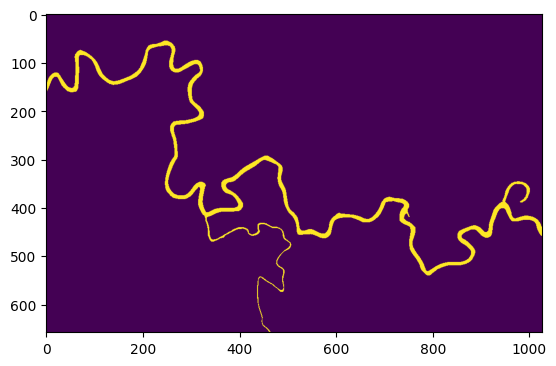

In [9]:
plt.imshow(murray)

Raster data is made up of regular cells over a defined region. The easiest way to think of these cells are as a grid of locations.

In [11]:
import numpy as np

In [14]:
rows, cols = np.argwhere(murray).T

To transform for grid cells to projected map coordinates you can use the affine transformation defined for this raster.

In [21]:
x, y = transform * (cols, rows)  # note the order of cols and rows is flipped here

And then to take the projected coordinates and convert them to a geopandas geodataframe. Note you should supply the CRS so the data could be reprojected if required.

In [20]:
import geopandas as gpd

In [25]:
points = gpd.GeoSeries(gpd.points_from_xy(x, y, crs=murray_crs))

<Axes: >

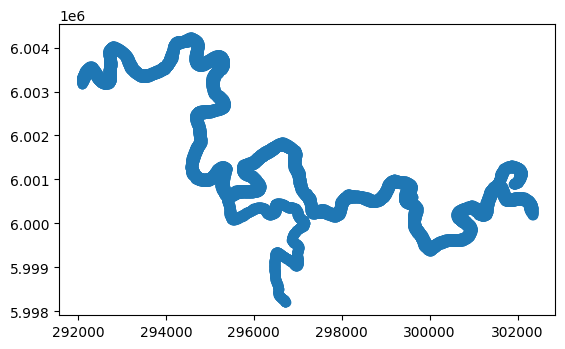

In [33]:
points.plot()

Unfortunately a surface represented as a series of points is often the least useful way to represent that data. Much better instead if you can convert this data into vector polygons. For this you can use the tools that are available in the rasterio library:

In [34]:
from rasterio import features

The `shapes` function returns an iterable of geojson polygons made up of contiguous cells with the same value, along with the value itself. Note that it a transform is not supplied then it defaults to the identity transform and the geojson coordinates will be the cell coordinates (i.e. x, y as row, column).

In [38]:
for geojson, value in features.shapes(murray, transform=transform):
    print(geojson)
    break

{'type': 'Polygon', 'coordinates': [[(301540.0, 6000900.0), (301540.0, 6000890.0), (301550.0, 6000890.0), (301550.0, 6000900.0), (301540.0, 6000900.0)]]}


Optionally you can supply a mask raster of boolean values to limit the polygons to only those values where the mask is `True`. The geojson is useful but by itself does not give you for example a shapely geometry object. But transforming geojson into a shapely geometry is easy:

In [37]:
from shapely import geometry

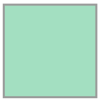

In [39]:
geometry.shape(geojson)

### Exercise: Create a geodataframe of polygons and values

Rather than creating an individual polygon, create a full geodataframe that contains the full polygon of the river Murray, without background values.

In [51]:
# %load solutions/rasterization_polygons.py

## Converting the raster into a line with skeletonization

This data represents a river. A polygon is useful but a line migh be _more_ useful. Creating a line that represents the centreline of the river can be done from the exterior polygon using Voronoi tesselations. But for large regions, complex boundaries or oddly shaped polygons this can require substantial processing. Instead you can can use the technique of Skeletonization to convert raster polygons into one pixel wide pixel lines. The scikit-image library contains functions to help with skeletonization:

In [59]:
subset = murray[340:440, -100:]

In [67]:
from skimage.morphology import skeletonize, medial_axis

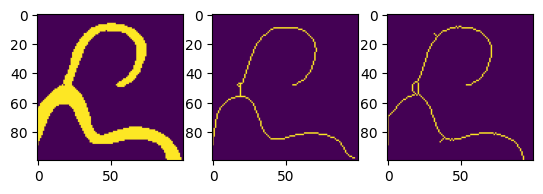

In [68]:
fig, axes = plt.subplots(ncols=3)
axes[0].imshow(subset)
axes[1].imshow(skeletonize(subset))
axes[2].imshow(medial_axis(subset))

The `skeletonize` function successively removes pixels from the foreground object provided that it maintains the connectivity of the object. The medial axis on the other hand is the set of pixels that is equidistant to 2 or more edge polygons. Depending on the structure of your data one method may give better results than another. For linear features typically the skeltonize method is the most useful.

The result of the skeletonization is still a raster, so to transform this set of pixels to a geometry line (or lines) still requires steps to link these vertices together.

In [70]:
rows, cols = np.argwhere(skeletonize(subset)).T

It's easiest at this point to use the affine transformation to get x and y coordinates of each point once again.

In [71]:
x, y = transform * (cols, rows)

To transform these points into longer lines reqires linking the points together. To do so you need to start by calculating the segments made up of adjacent point pairs. You can do this with nestec `for` loops but this is inefficient. Instead the best tool to use to find these pair is the `KDTree` from `scipy.spatial`.

In [74]:
from scipy.spatial import KDTree

In [78]:
coords = np.column_stack([x, y])
tree = KDTree(coords)

From the tree object you can query adjacent points using the `query_pairs` method. Depending on whether you wish to include diagonal connectivity or only straight-line connectivity you can adjust the radius based on the cell size. Assuming diagonal connectivity, and knowing the cell size of this raster is 10 metres, you can use:

In [86]:
pairs = tree.query_pairs(np.sqrt(2 * 10**2))
lines = [
    geometry.LineString([coords[start], coords[end]])
    for start, end in pairs
]

And then the shapely library has a helpful `linemerge` function to join successive lines into a single geometry.

In [87]:
from shapely.ops import linemerge

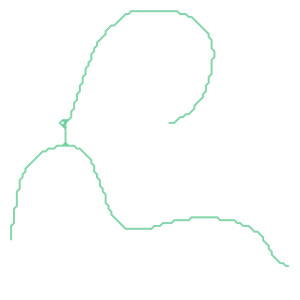

In [90]:
river = linemerge(lines)
river

Note that there are likely excess lines where branches of the river merge using this algorithm, along with regions of high noise in the boundary. To remove this requires an additional cleanup step. In the intersections of the river branch because there are extra lines joining each segment the longer lines are broken into shorter segments. You can therefore remove some of those shorter segments. Not the segments of length 10 (the cell size), but the length of the diagonal. Do this because you know where the branches join the join should be at 90&deg;.

In [100]:
segments = [seg for seg in river.geoms if not np.allclose(seg.length, np.sqrt(2 * 10**2))]

In [102]:
river = linemerge(segments)

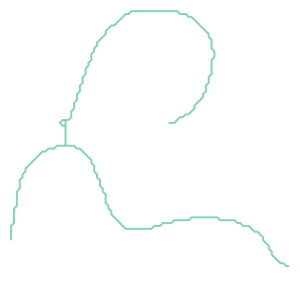

In [105]:
river

### Exercise: How long is this segment of the river Murray?

Calculate the skeleton of the full dataset of the river Murray, and convert it into a line geometry. How long is the river? What is the difference in length between the rivers when performing the same geometry creation process on the results of the `medial_axis` function.

In [119]:
# %load solutions/skeleton_murray.py

## Converting from vector to raster

Converting from vector to raster is a process which requires more initial choices but in the end is a single step process. One obvious reason you might want to do this is to calculate raster statistics for a polygon region. In this example you will use the Melbourne buildings dataset and convert the building footprints to a raster dataset.

In [120]:
import geopandas as gpd

<Axes: >

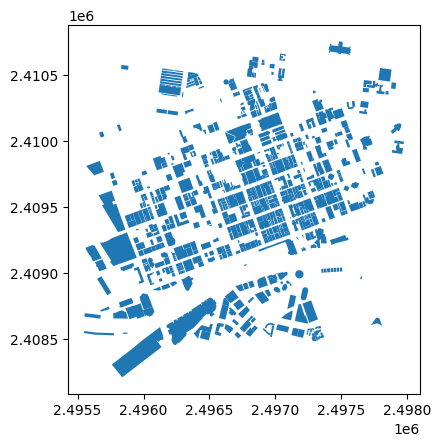

In [122]:
buildings = gpd.read_file("/Data/spatial/melbourne_buildings.shp")
buildings.plot()

To create a raster you need to make some decisions - specifically the raster origin (the top left corner), and the cell size for the raster. From this you must derive the shape of the output raster (the number of rows and columns), and the affine object transforming to and from raster cell and projected coordinates. In this example you'll create a raster with 10 metre cell size. Start by examining the dataset bounds and we can use this to calculate a top left corner.

In [125]:
min_x, min_y, max_x, max_y = buildings.total_bounds

In [127]:
cellsize = 10

In [136]:
left = np.floor(min_x / cellsize) * cellsize
right = np.ceil(max_x / cellsize) * cellsize

bottom = np.floor(min_y / cellsize) * cellsize
top = np.ceil(max_y / cellsize) * cellsize

So the top left corner is:

In [139]:
left, top

(np.float64(2495540.0), np.float64(2410760.0))

And the size of the output array is:

In [140]:
width = int((right - left) / cellsize)
height = int((top - bottom) / cellsize)

And finally you can create the affine object:

In [143]:
from affine import Affine

In [146]:
transform = Affine(
    cellsize,  # x cellsize
    0,  # rotation in x
    left,  # x origin
    0,  # rotation in y
    -cellsize,  # y cellsize (from the top, so negative)
    top,  # y origin
)

And finally we can rasterize the vector dataset:

In [149]:
building_raster = features.rasterize(
    buildings["geometry"],
    out_shape=(height, width),
    transform=transform,
    all_touched=True
)

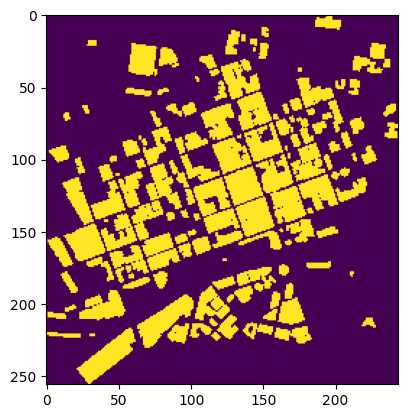

In [151]:
plt.imshow(building_raster)

Note that you don't need the CRS until you go to write the new raster out to a file on disk.